# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 163.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 48.3 MB/s eta 0:00

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [76]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [77]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [78]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/AI_ML Course/project06/images.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/AI_ML Course/project06/labels.csv')

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [79]:
# Check the shape of the data
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


* As stated in the Data Description section,  we have 4125 images that are 200 x 200 with 3 channels.
* Also, we have 4125 corresponding labels for the image set that label each image with a 1 (helmet found) or 0 (no helmet in image).

Label: 1


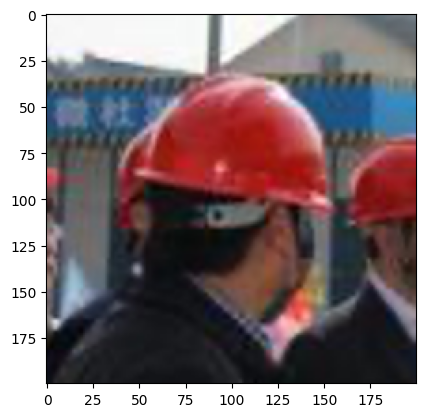

In [80]:
#show a random image from the set
plt.imshow(images[1555]);
#show how the image is labeled
print("Label:", labels['label'][1555])

Label: 0


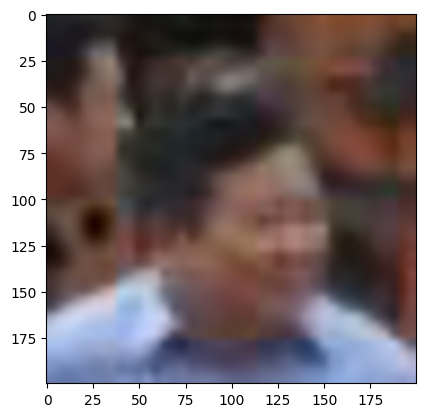

In [81]:
#show a random image from the set
plt.imshow(images[399]);
#show how the image is labeled
print("Label:", labels['label'][399])

* The first image shows a person wearing a helmet and is properly labeled with a 1.
* The second image shows a person not wearing a helmet and is properly labeled with a 0.

## Checking for class imbalance


In [82]:
#print the number of labels with value 0
print("Negative count:", (labels['label'] == 0).sum())
#print the number of labels with value 1
print("Positive count:", (labels['label'] == 1).sum())

Negative count: 964
Positive count: 3161


* This dataset has 964 images (23%) with no helmet and 3161 images (77%) with a helmet.
* This is a moderately imbalanced data set.

# **Data Preprocessing**

### Splitting the dataset



- Use 10% of data for testing, 10% for validation and 80% for training.

In [83]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [84]:
#Check the shapes of split data
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3300, 200, 200, 3) (3300, 1)
(412, 200, 200, 3) (412, 1)
(413, 200, 200, 3) (413, 1)


### Data Normalization

In [85]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [86]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [87]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [134]:
tf.keras.backend.clear_session()

In [135]:
model_0 = Sequential()

# Add the first convolutional layer and max pooling layer
model_0.add(Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)))
model_0.add(MaxPooling2D((2, 2)))

# Add a second convolutional and max pooling layer
model_0.add(Conv2D(64, (3, 3), activation='relu'))
model_0.add(MaxPooling2D((2, 2)))

# Flatten the 2D feature maps to a 1D vector
model_0.add(Flatten())

# Add fully connected layers
model_0.add(Dense(128, activation='relu'))
model_0.add(Dense(1, activation='sigmoid')) # Single neuron with sigmoid for binary output


In [136]:
opt=Adam()
# Compile model
model_0.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [137]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,894,017 (72.07 MB)

 Trainable params: 18,894,017 (72.07 MB)

 Non-trainable params: 0 (0.00 B)

In [138]:
train_datagen = ImageDataGenerator()

In [139]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_scratch = model_0.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.7002 - loss: 1.5738 - val_accuracy: 0.7670 - val_loss: 0.5047
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7734 - loss: 0.4754 - val_accuracy: 0.7670 - val_loss: 0.5021
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.7654 - loss: 0.4653 - val_accuracy: 0.7670 - val_loss: 0.4163
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7891 - loss: 0.4164 - val_accuracy: 0.7670 - val_loss: 0.4175
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.8090 - loss: 0.3427 - val_accuracy: 0.8908 - val_loss: 0.2551
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8359 - loss: 0.3542 - val_accuracy: 0.9053 - val_loss: 0.2430
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9045 - loss: 0.2464 - val_accuracy: 0.8762 - val_loss: 0.2674
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9062 - loss: 0.2537 - val_accuracy: 0.8981

### Visualizing the predictions

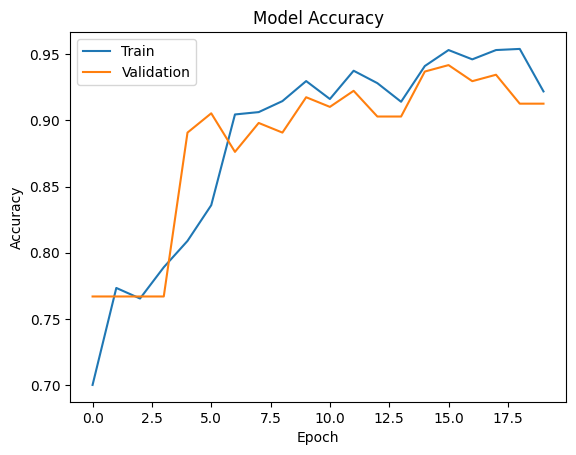

In [140]:
plt.plot(history_scratch.history['accuracy'])
plt.plot(history_scratch.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [141]:
model_0_train_perf = model_performance_classification(model_0, X_train_normalized,y_train)
print("Train performance metrics")
print(model_0_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.948182  0.948182   0.948182  0.948182


104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


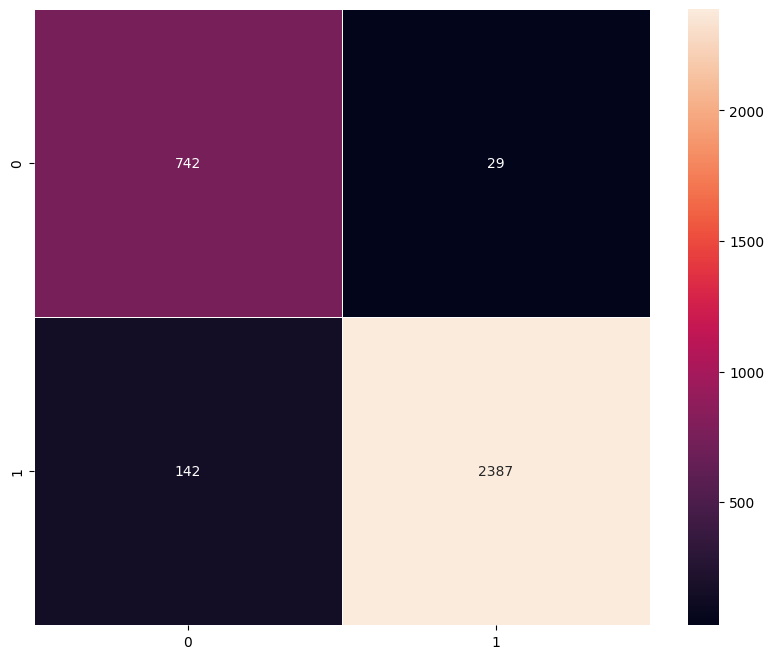

In [142]:
plot_confusion_matrix(model_0,X_train_normalized,y_train)

In [143]:
model_0_valid_perf = model_performance_classification(model_0, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_0_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.912621  0.912621   0.912621  0.912621


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


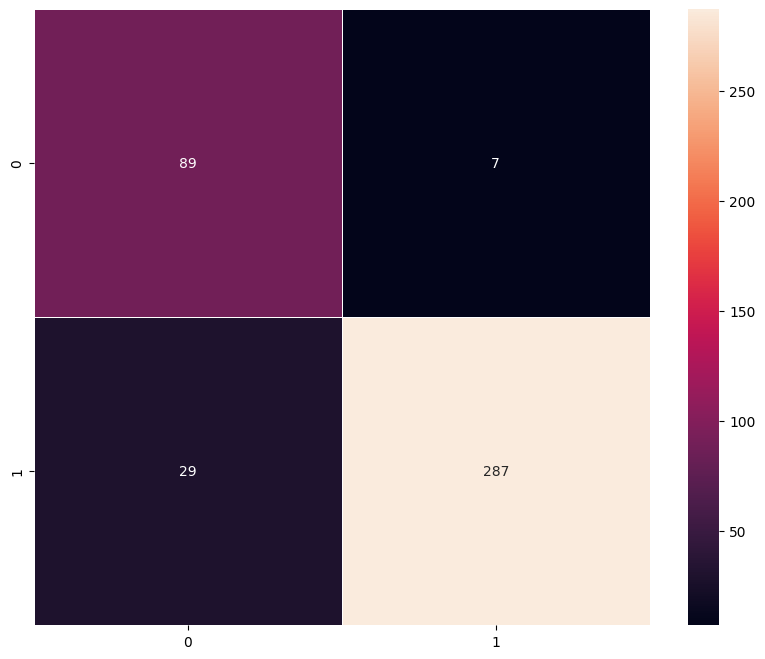

In [144]:
plot_confusion_matrix(model_0,X_val_normalized,y_val)

- The model has achieved approximately 95% accuracy on the training set and 91% accuracy on the validation set.
- The model is overfitting the data.


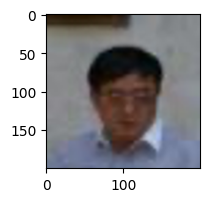

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Label [[0.0161652]]
True Label 0


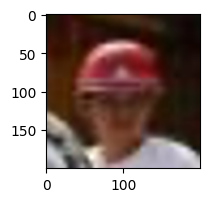

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Label [[0.998486]]
True Label 1


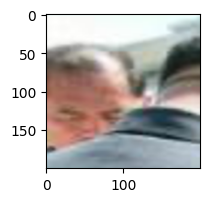

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Label [[0.15663324]]
True Label 0


In [145]:
# Visualizing the predicted and correct label of images
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', model_0.predict((X_val_normalized[2].reshape(1,200,200,3))))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
print('Predicted Label', model_0.predict((X_val_normalized[200].reshape(1,200,200,3))))
print('True Label', y_val.iloc[200]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[400])
plt.show()
print('Predicted Label', model_0.predict((X_val_normalized[400].reshape(1,200,200,3))))
print('True Label', y_val.iloc[400]['label'])

## Model 2: Transfer Learning with VGG-16 (Base)

In [146]:
tf.keras.backend.clear_session()

In [147]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [149]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [150]:
model_1 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_1.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_1.add(Flatten())

# Adding dense hidden layer
model_1.add(Dense(256,activation='relu'))

# Add a dropout layer
model_1.add(Dropout(rate=0.4))

# Adding a dense output layer
model_1.add(Dense(1, activation='sigmoid'))

In [151]:
opt=Adam()
# Compile model
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [152]:
# Generating the summary of the model
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [153]:
train_datagen = ImageDataGenerator()

In [154]:
# Epochs
epochs = 20
# Batch size
batch_size = 128

history_vgg16 = model_1.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 816ms/step - accuracy: 0.7888 - loss: 0.6030 - val_accuracy: 0.8519 - val_loss: 0.3139
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8594 - loss: 0.3138 - val_accuracy: 0.8568 - val_loss: 0.3098
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 824ms/step - accuracy: 0.8673 - loss: 0.2904 - val_accuracy: 0.8641 - val_loss: 0.2877
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8906 - loss: 0.2453 - val_accuracy: 0.8811 - val_loss: 0.2673
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 859ms/step - accuracy: 0.9057 - loss: 0.2316 - val_accuracy: 0.9078 - val_loss: 0.2321
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9219 - loss: 0.2144 - val_accuracy: 0.8908 - val_loss: 0.2427
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 830ms/step - accuracy: 0.9139 - loss: 0.2002 - val_accuracy: 0.9078 - val_loss: 0.2094
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8984 - loss: 0.2145 - val_accuracy: 0.

### Visualizing the predictions

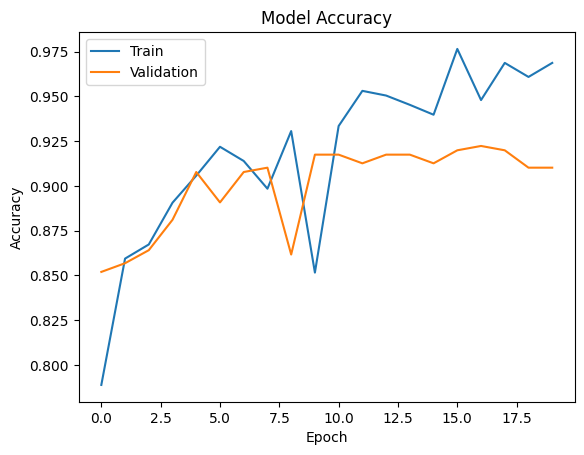

In [155]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [156]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step
Train performance metrics
   Accuracy   Recall  Precision  F1 Score
0   0.97697  0.97697    0.97697   0.97697


104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step


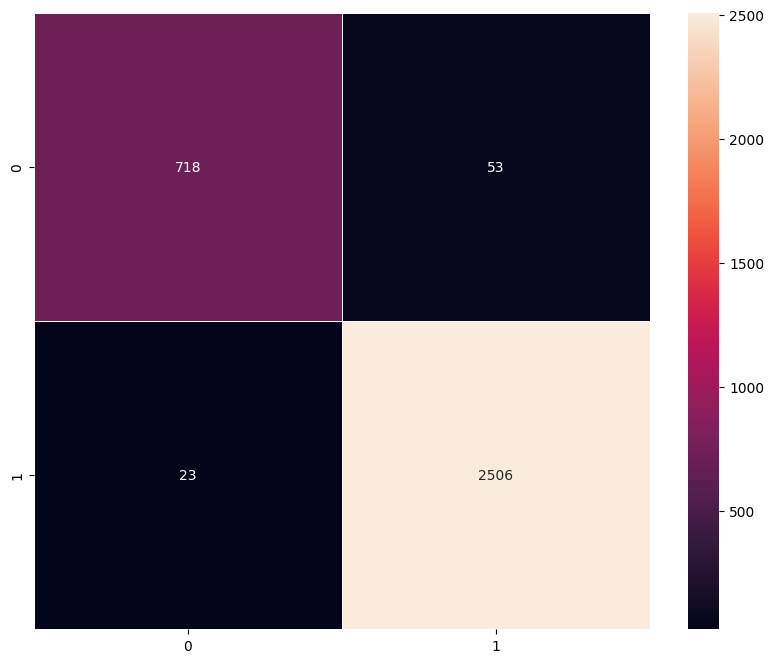

In [157]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [158]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.910194  0.910194   0.910194  0.910194


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step


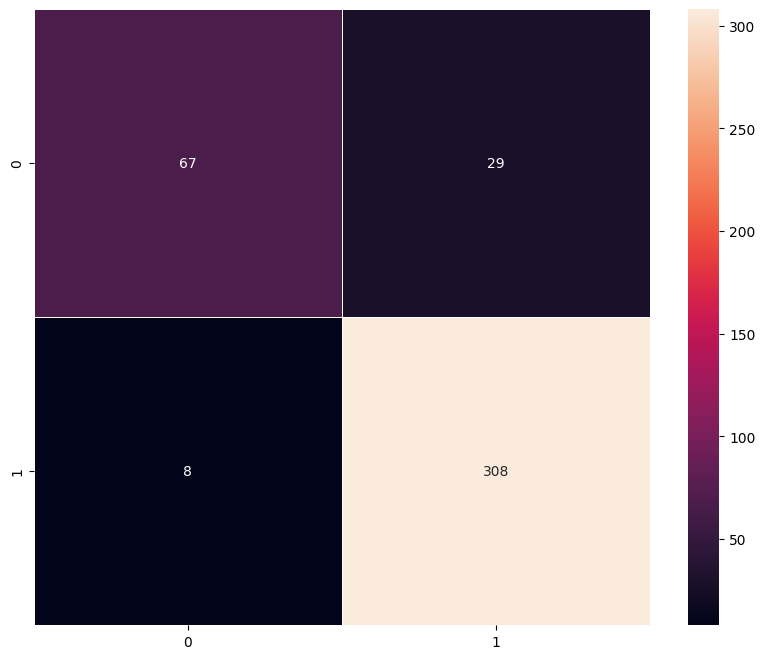

In [159]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

- The model has achieved approximately 98% accuracy on the training set and 91% accuracy on the validation set.
- This model is also overfitting the training data.

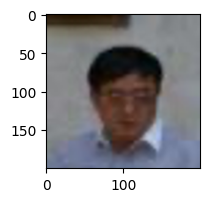

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Label [[0.02456095]]
True Label 0


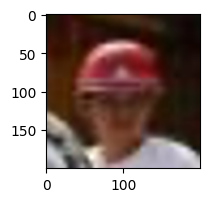

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Label [[0.9941718]]
True Label 1


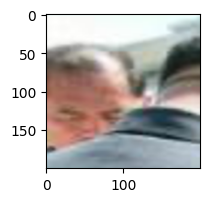

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Label [[0.6767289]]
True Label 0


In [160]:
# Visualizing the predicted and correct label of images
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[2].reshape(1,200,200,3))))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[200].reshape(1,200,200,3))))
print('True Label', y_val.iloc[200]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[400])
plt.show()
print('Predicted Label', model_1.predict((X_val_normalized[400].reshape(1,200,200,3))))
print('True Label', y_val.iloc[400]['label'])



## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [161]:
tf.keras.backend.clear_session()

In [162]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

#Adding the Feed Forward neural network
model_2.add(Dense(256,activation='relu'))
model_2.add(Dropout(rate=0.4))
model_2.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

opt = Adam()

In [163]:
# Compile model
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [164]:
# Generating the summary of the model
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [165]:
history_vgg16 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 863ms/step - accuracy: 0.7213 - loss: 0.6869 - val_accuracy: 0.7670 - val_loss: 0.4220
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7969 - loss: 0.4494 - val_accuracy: 0.7718 - val_loss: 0.4176
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 870ms/step - accuracy: 0.8080 - loss: 0.4036 - val_accuracy: 0.8592 - val_loss: 0.3071
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8516 - loss: 0.3538 - val_accuracy: 0.8519 - val_loss: 0.3162
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 838ms/step - accuracy: 0.8730 - loss: 0.2865 - val_accuracy: 0.8665 - val_loss: 0.2792
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8750 - loss: 0.2504 - val_accuracy: 0.8908 - val_loss: 0.2545
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 802ms/step - accuracy: 0.8966 - loss: 0.2507 - val_accuracy: 0.9078 - val_loss: 0.2364
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8984 - loss: 0.2414 - val_accuracy: 0.

#### Visualizing the predictions

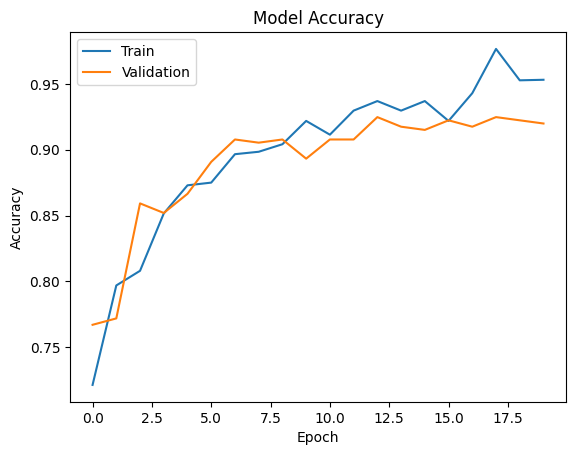

In [166]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [167]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.968788  0.968788   0.968788  0.968788


104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step


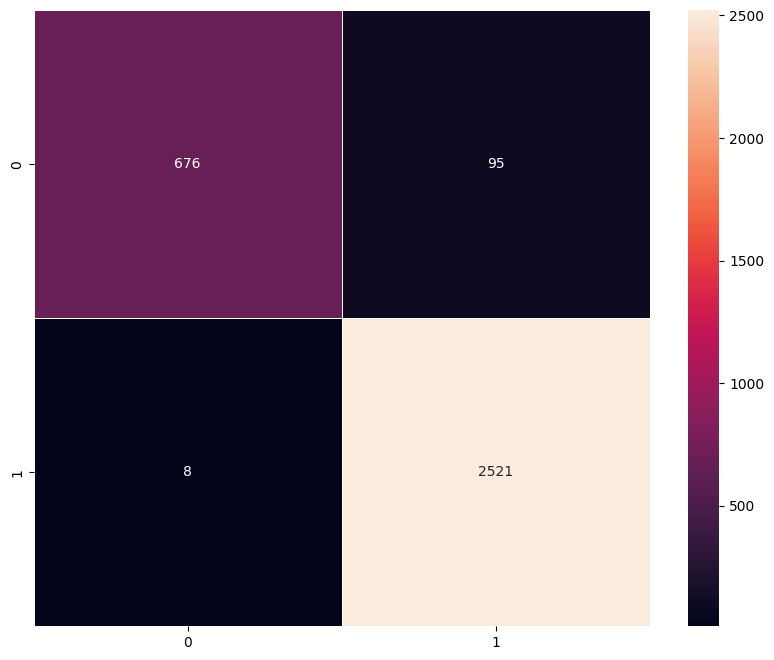

In [168]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [169]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.919903  0.919903   0.919903  0.919903


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step


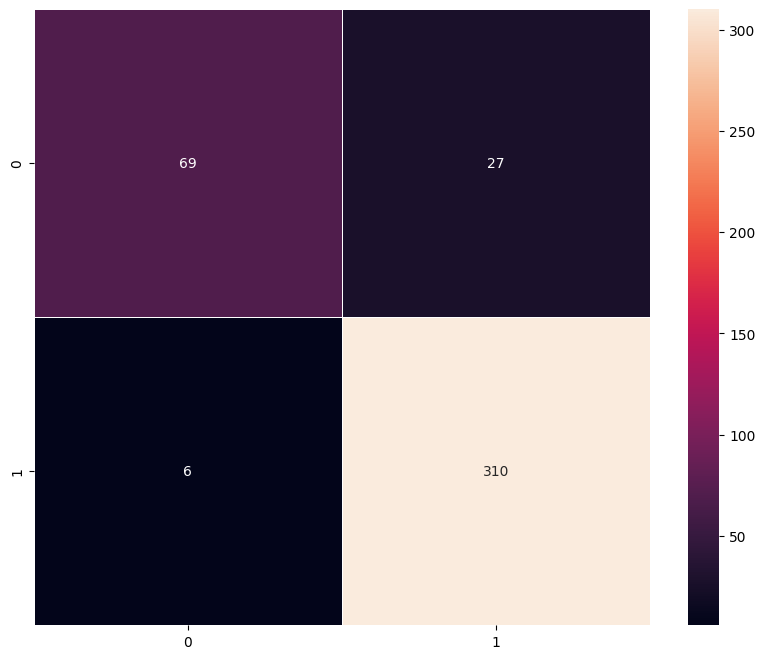

In [170]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

- The model has achieved approximately 97% accuracy on the training set and 92% accuracy on the validation set.

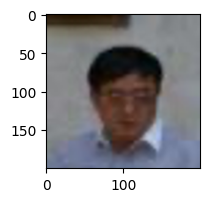

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Label [[0.02447481]]
True Label 0


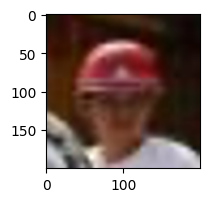

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Label [[0.99575883]]
True Label 1


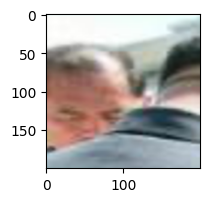

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Label [[0.51613975]]
True Label 0


In [171]:
# Visualizing the predicted and correct label of images
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', model_2.predict((X_val_normalized[2].reshape(1,200,200,3))))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
print('Predicted Label', model_2.predict((X_val_normalized[200].reshape(1,200,200,3))))
print('True Label', y_val.iloc[200]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[400])
plt.show()
print('Predicted Label', model_2.predict((X_val_normalized[400].reshape(1,200,200,3))))
print('True Label', y_val.iloc[400]['label'])



## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [172]:
tf.keras.backend.clear_session()

In [173]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [174]:
opt=Adam()
# Compile model
model_3.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [175]:
# Generating the summary of the model
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [176]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',
                              width_shift_range=0.2,
                              height_shift_range=0.2,
                              shear_range=0.3,
                              zoom_range=0.4
                              )

In [177]:
history_vgg16 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.7169 - loss: 0.6440 - val_accuracy: 0.7670 - val_loss: 0.4445
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7344 - loss: 0.5681 - val_accuracy: 0.7670 - val_loss: 0.4401
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7768 - loss: 0.4672 - val_accuracy: 0.8398 - val_loss: 0.3443
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8047 - loss: 0.4090 - val_accuracy: 0.8398 - val_loss: 0.3461
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8064 - loss: 0.4071 - val_accuracy: 0.8714 - val_loss: 0.3188
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8203 - loss: 0.3795 - val_accuracy: 0.8762 - val_loss: 0.3129
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8165 - loss: 0.3868 - val_accuracy: 0.8544 - val_loss: 0.2986
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.8125 - loss: 0.4208 - val_accuracy: 0.8835 - val_l

#### Visualizing the predictions

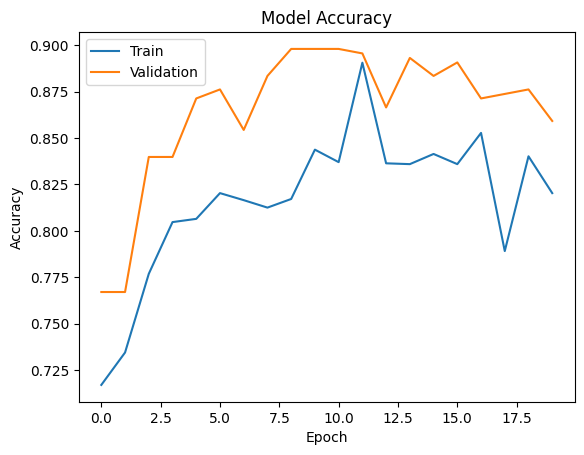

In [178]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [179]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.875152  0.875152   0.875152  0.875152


104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step


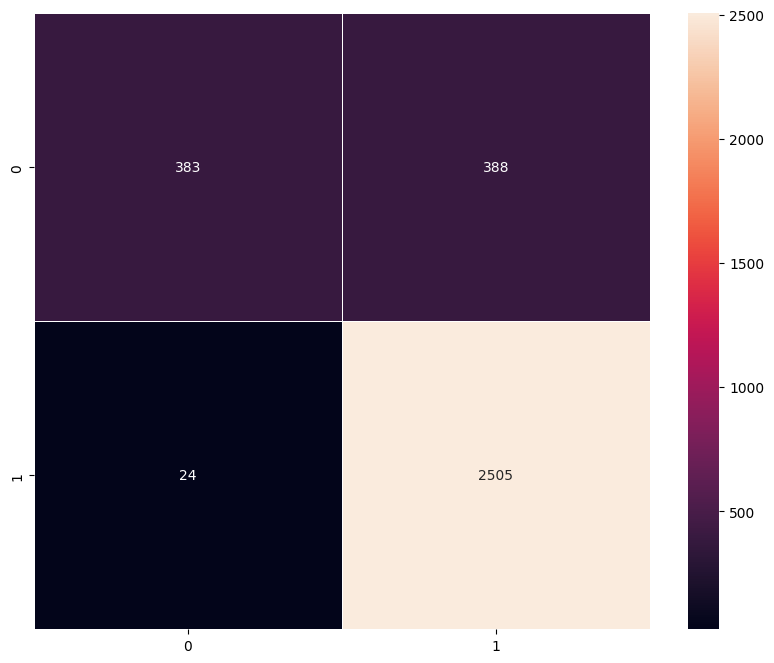

In [180]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [181]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.859223  0.859223   0.859223  0.859223


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step


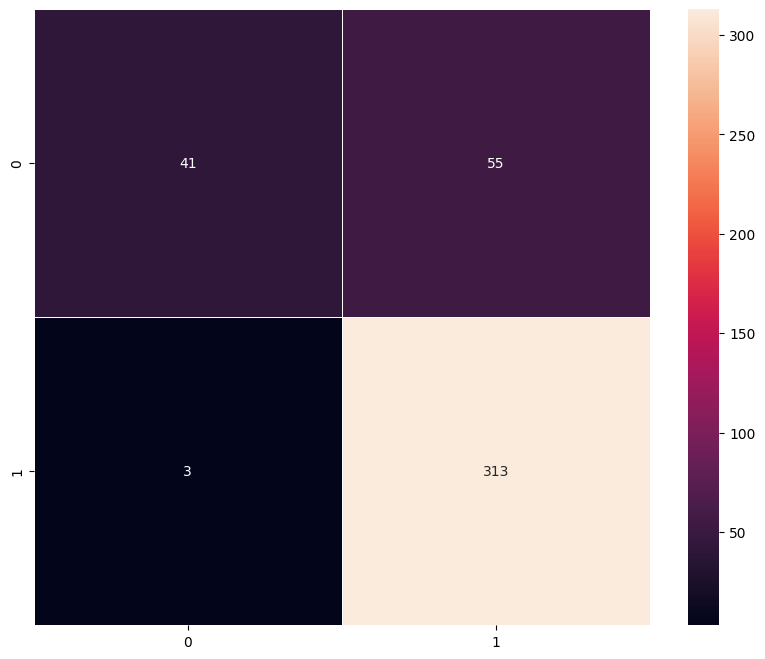

In [182]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

- The model has achieved approximately 88% accuracy on the training set and 86% accuracy on the validation set.
- It is overfitting less than other models, but the accuracy has suffered slightly.

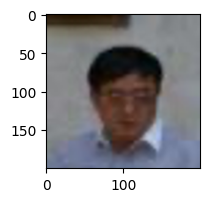

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label [[0.24160585]]
True Label 0


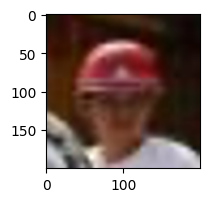

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label [[0.83623594]]
True Label 1


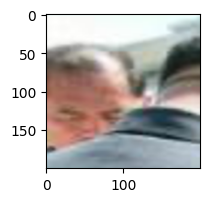

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Label [[0.8613863]]
True Label 0


In [183]:
# Visualizing the predicted and correct label of images
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
print('Predicted Label', model_3.predict((X_val_normalized[2].reshape(1,200,200,3))))
print('True Label', y_val.iloc[2]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
print('Predicted Label', model_3.predict((X_val_normalized[200].reshape(1,200,200,3))))
print('True Label', y_val.iloc[200]['label'])

plt.figure(figsize=(2,2))
plt.imshow(X_val[400])
plt.show()
print('Predicted Label', model_3.predict((X_val_normalized[400].reshape(1,200,200,3))))
print('True Label', y_val.iloc[400]['label'])



# **Model Performance Comparison and Final Model Selection**

In [192]:
#Print model performance for comparison
print("Convolutional Neural Network (CNN) from Scratch")
print(model_0_valid_perf)
print("---------------------------------")
print("Transfer Learning with VGG-16 (Base)")
print(model_1_valid_perf)
print("---------------------------------")
print("Transfer Learning with VGG-16 (Base + FFNN)")
print(model_2_valid_perf)
print("---------------------------------")
print("Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)")
print(model_3_valid_perf)

Convolutional Neural Network (CNN) from Scratch
   Accuracy    Recall  Precision  F1 Score
0  0.912621  0.912621   0.912621  0.912621
---------------------------------
Transfer Learning with VGG-16 (Base)
   Accuracy    Recall  Precision  F1 Score
0  0.910194  0.910194   0.910194  0.910194
---------------------------------
Transfer Learning with VGG-16 (Base + FFNN)
   Accuracy    Recall  Precision  F1 Score
0  0.919903  0.919903   0.919903  0.919903
---------------------------------
Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)
   Accuracy    Recall  Precision  F1 Score
0  0.859223  0.859223   0.859223  0.859223


- Based on model performance, I would choose the model using Transfer Learning with VGG-16 (Base + FFNN) because it provides the best accuracy of the 4 models along with the highest precision.
- Having a higher precision helps reduce false positives.
- A false positive in this business case means the model detects a helmet being worn when in fact it is not worn, which causes a dangerous condition for the person in the image.  We want to minimize this scenario.  

## Test Performance

In [193]:
model_2_test_perf = model_performance_classification(model_2, X_test_normalized,y_test)
model_2_test_perf

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.876513,0.876513,0.876513,0.876513


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step


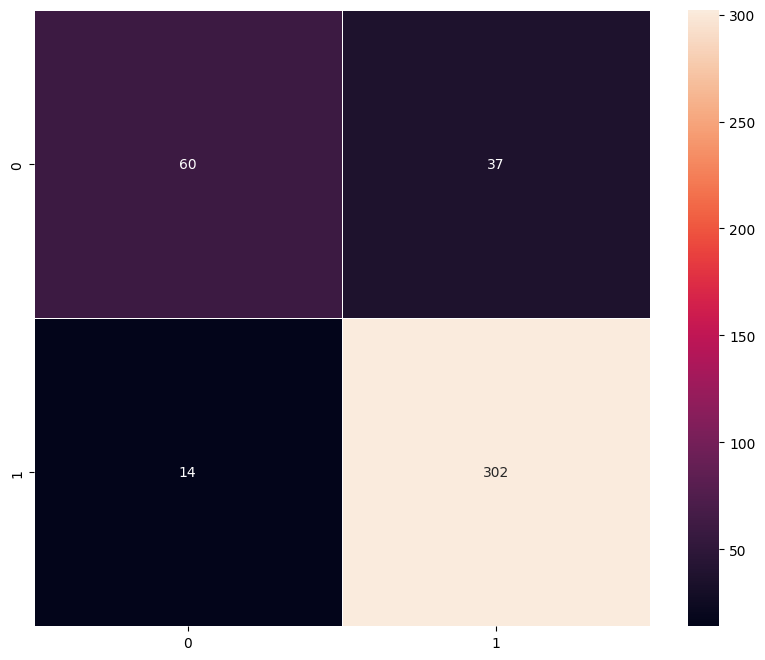

In [194]:
plot_confusion_matrix(model_2, X_test_normalized,y_test)

- Accuracy and precision fall to about 88% on the test set using the Transfer Learning with VGG-16 (Base + FFNN) model.  
- This is below the accuracy and precision on training and validation sets.

# **Actionable Insights & Recommendations**

- Adding a feed-forward neural network on top of the VGG-16 model improved performance. This suggests that while the pre-trained features were beneficial, further refining them with an additional neural network tailored to our dataset enhanced the results.

- Applying data augmentation techniques made the model worse in terms of accuracy and recall compared with Transfer Learning with VGG-16 (Base + FFNN) without data augmentation.  This suggests that data augmentation is not appopriate with this data set.  Also, training time was significantly increased when using data augmentation.

- Higher quality images could help with training a more effective model.  Many images are not clear, despite being 200 x 200 size.

<font size=5 color='blue'>Power Ahead!</font>
___